## Ejercicio: **Transfer Learning y Fine Tuning**


### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
from sklearn.utils import shuffle
from tensorflow.keras.applications.resnet_v2 import ResNet50V2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras import layers
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam
from tensorflow.keras import Model
import pandas as pd

In [1]:
carpetas = [nombre for nombre in os.listdir(ruta) if os.path.isdir(os.path.join(ruta, nombre))]
print(carpetas)


NameError: name 'os' is not defined

In [6]:
class_names = carpetas
class_names_label = {class_name:i for i ,class_name in enumerate(class_names)}
class_names_label

{'Braeburn': 0,
 'CrimsonSnow': 1,
 'Golden1': 2,
 'Golden2': 3,
 'Golden3': 4,
 'GrannySmith': 5,
 'PinkLady': 6,
 'Red1': 7,
 'Red2': 8,
 'Red3': 9,
 'RedDelicious': 10,
 'RedYellow1': 11,
 'RedYellow2': 12}

In [9]:

IMAGE_SIZE = (100,100)
train_path1 = r"train"
test_path1 = r"test"

In [10]:
def read_data(path, im_size, class_names_label):
    X = []
    y = []

    for folder in os.listdir(path):
        label = class_names_label[folder]
        folder_path = os.path.join(path,folder)
        # Iterar sobre todo lo que haya en path
        for file in os.listdir(folder_path):
            image_path = os.path.join(folder_path,file)
            image = cv2.imread(image_path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = cv2.resize(image, im_size)
            X.append(image)
            y.append(label)


    return np.array(X), np.array(y)


X_train, y_train = read_data(train_path1, IMAGE_SIZE, class_names_label)
X_test, y_test = read_data(test_path1, IMAGE_SIZE, class_names_label)

print(X_train.shape)
print(X_test.shape)


(6404, 100, 100, 3)
(2134, 100, 100, 3)


In [11]:
from sklearn.utils import shuffle

X_train, y_train = shuffle(X_train, y_train, random_state=42)

In [12]:
y_train[0:10]

array([ 5, 11,  5,  2, 10,  5,  4,  1, 10,  9])

In [13]:
import pandas as pd
pd.DataFrame(y_train).value_counts()

0 
12    672
0     492
3     492
5     492
7     492
8     492
11    492
10    490
4     481
2     480
6     456
1     444
9     429
Name: count, dtype: int64

In [14]:
X_train.max()

255

Red3


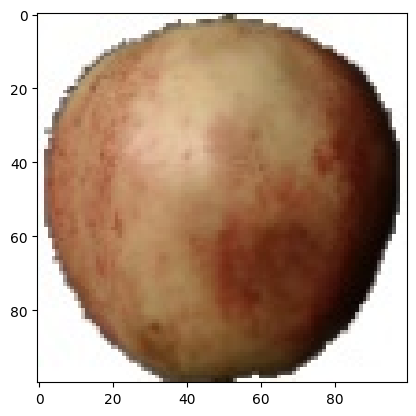

In [15]:
import matplotlib.pyplot as plt
index = np.random.randint(X_train.shape[0])
print(class_names[y_train[index]])
plt.imshow(X_train[index]);

In [16]:
X_train_scal = X_train/255.0
X_test_scal = X_test/255.0

In [17]:
IMAGE_SIZE
input_shape = (100, 100, 3)

In [18]:
X_train_scal.shape

(6404, 100, 100, 3)

In [33]:
from tensorflow.keras.utils import to_categorical

# Si tus etiquetas son números enteros (0 a 12), conviértelas:
y_train_one_hot = to_categorical(y_train, num_classes=13)
y_test_one_hot = to_categorical(y_test, num_classes=13)

In [37]:
X_train_final = (X_train_scal * 2) - 1
X_test_final = (X_test_scal * 2) - 1

In [48]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(100, 100, 3))
base_model.trainable = False  # Congelamos el modelo base

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dense(13, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', # Para etiquetas en formato 0, 1, 2...
    metrics=['accuracy']
)

In [42]:
model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Funct  (None, 4, 4, 1280)       2257984   
 ional)                                                          
                                                                 
 global_average_pooling2d_7   (None, 1280)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dense_21 (Dense)            (None, 256)               327936    
                                                                 
 dropout_8 (Dropout)         (None, 256)               0         
                                                                 
 dense_22 (Dense)            (None, 128)               32896     
                                                                 
 dense_23 (Dense)            (None, 13)               

In [43]:
model.fit(X_train_final, y_train, validation_data=(X_test_final, y_test), epochs=5)

Epoch 1/5
201/201 [==============================] - 6s 20ms/step - loss: 0.2006 - accuracy: 0.9369 - val_loss: 0.1521 - val_accuracy: 0.9442
Epoch 2/5
201/201 [==============================] - 3s 14ms/step - loss: 0.0066 - accuracy: 0.9992 - val_loss: 0.1925 - val_accuracy: 0.9344
Epoch 3/5
201/201 [==============================] - 3s 16ms/step - loss: 0.0027 - accuracy: 0.9995 - val_loss: 0.2054 - val_accuracy: 0.9274
Epoch 4/5
201/201 [==============================] - 3s 14ms/step - loss: 0.0323 - accuracy: 0.9889 - val_loss: 0.5821 - val_accuracy: 0.8772
Epoch 5/5
201/201 [==============================] - 3s 14ms/step - loss: 0.0241 - accuracy: 0.9909 - val_loss: 0.2385 - val_accuracy: 0.9424


67/67 [==============================] - 1s 9ms/step

--- Resultado Final (Fine-Tuning): REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       164
           1       0.00      0.00      0.00       148
           2       0.00      0.00      0.00       160
           3       0.00      0.00      0.00       164
           4       0.00      0.01      0.00       161
           5       0.00      0.00      0.00       164
           6       0.08      0.66      0.13       152
           7       0.00      0.00      0.00       164
           8       0.00      0.00      0.00       164
           9       0.00      0.00      0.00       144
          10       0.00      0.00      0.00       166
          11       0.50      0.03      0.06       164
          12       0.00      0.00      0.00       219

    accuracy                           0.05      2134
   macro avg       0.04      0.05      0.02      2134
weighted avg    

c:\Users\danil\miniconda3\envs\tf_gpu\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\danil\miniconda3\envs\tf_gpu\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\danil\miniconda3\envs\tf_gpu\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

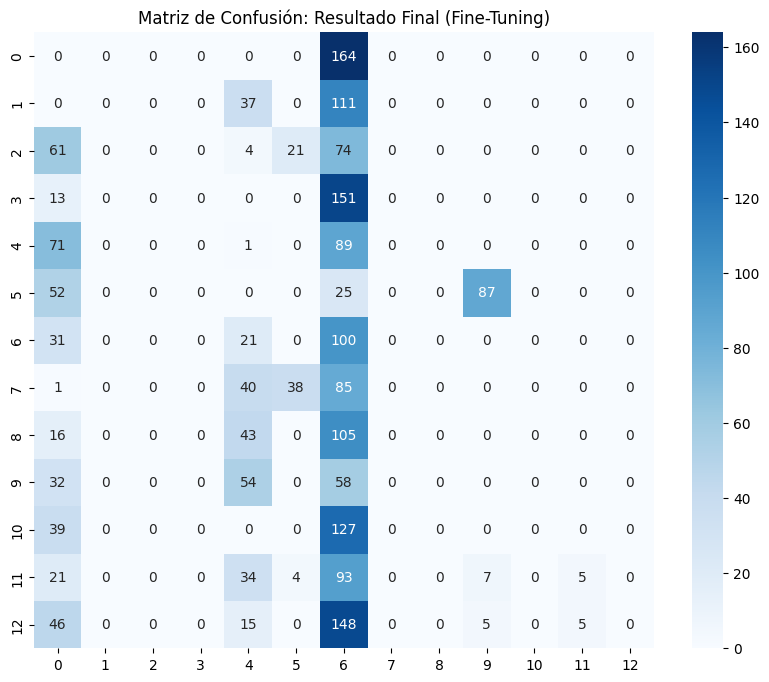

In [49]:
# --- EVALUACIÓN FINAL ---
def mostrar_metricas(model, X, y, titulo):
    y_pred = np.argmax(model.predict(X), axis=1)
    
    print(f"\n--- {titulo}: REPORTE DE CLASIFICACIÓN ---")
    print(classification_report(y, y_pred))
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(confusion_matrix(y, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de Confusión: {titulo}')
    plt.show()

mostrar_metricas(model, X_test_final, y_test, "Resultado Final (Fine-Tuning)")

### Objetivo del ejercicio

Comparar una red convolucional hecha ad-hoc frente a los modelos preentrenados y ajustados con fine tuning y transfer learning. Para ello emplea el dataset de paisajes del conjunto de ejercicios de la unidad anterior.


### Se pide

1. Preparar los datos del modelo y las funciones de visualización, copia para ello todo lo que necesites de las soluciones del ejercicio de clasificación de paisajes de la unidad anterior.

2. Escoger entre uno de los modelos VGG-19, InceptionV3 y MobileNetV2 (todos en https://keras.io/api/applications/) (Se aconseja este último si no tenemos un ordenador muy potente). Si no te haces con estos puedes recurrir a la ResNetV50.

4. Hacer un transfer-learning con una cabeza de como mucho 2 capas densas ocultas y una de salida. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

5. Hacer un fine-tuning con la misma cabeza diseñada en el punto anterior. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

6. Comparar los resultados con los obtenidos con la red convolucional del ejercicio mencionado.

EXTRA:
- Repetir el transfer learning empleando aumentado de imágenes.

